In [1]:
from stim import __version__
print(__version__)

1.15.0


In [2]:
import stim
import numpy as np
import matplotlib.pyplot as plt

# Encoding Circuit

In [24]:
def logical_zero(qc: stim.Circuit, p1_err: float, p2_err: float):
    for i in range(3):
        qc.append("H", [i])
        qc.append("DEPOLARIZE1", [i], p1_err)
    cy_list = [[0, 1], [1, 2]]
    for cy in cy_list:
        qc.append("CY", cy)
        qc.append("DEPOLARIZE2", cy, p2_err)
    qc.append("CX", [0, 3])
    qc.append("DEPOLARIZE2", [0, 3], p2_err)
    qc.append("H", [0])
    qc.append("DEPOLARIZE1", [0], p1_err)
    qc.append("X", [0])
    qc.append("DEPOLARIZE1", [0], p1_err)
    qc.append("Z", [0])
    qc.append("DEPOLARIZE1", [0], p1_err)
    
def inverse_logical_zero(qc: stim.Circuit):
    qc.append("Z", [0])
    qc.append("X", [0])
    qc.append("H", [0])
    qc.append("CX", [0, 3])
    cy_list = [[1, 2], [0, 1]]
    for cy in cy_list:
        qc.append("CY", cy)
    for i in range(3):
        qc.append("H", [i])

In [7]:
def logical_hadamard(qc: stim.Circuit, p1_err: float, p2_err: float):
    qc.append("X", [0])
    qc.append("DEPOLARIZE1", [0], p1_err)
    qc.append("X", [2])
    qc.append("DEPOLARIZE1", [2], p1_err)
    for i in range(4):
        qc.append("H", [i])
        qc.append("DEPOLARIZE1", [i], p1_err)
    qc.append("X", [2])
    qc.append("DEPOLARIZE1", [2], p1_err)
    qc.append("Z", [3])
    qc.append("DEPOLARIZE1", [3], p1_err)

# Measurement Circuit

In [5]:
def final_measurements(qc: stim.Circuit, meas_err: float):
    qc.append("X_ERROR", range(4), meas_err)
    qc.append("MR", range(4))
    
    qc.append("OBSERVABLE_INCLUDE", [stim.target_rec(-4), stim.target_rec(-3), stim.target_rec(-2), stim.target_rec(-1)], 0)

# Entire Hadamard Circuit

In [25]:
def hadamard_circuit(qc: stim.Circuit, p1_err: float, p2_err: float, meas_err: float, rep: int):
    logical_zero(qc, p1_err=p1_err, p2_err=p2_err)
    
    for _ in range(2*rep):
        logical_hadamard(qc, p1_err=p1_err, p2_err=p2_err)
    
    inverse_logical_zero(qc)
    final_measurements(qc, meas_err=meas_err)

# Decoder

In [9]:
def decoder(obs):
    shots = obs.shape[0]
    error = 0
    
    for i in range(shots):
        if (obs[i][0]):
            error += 1
    err_rate = error/shots
    unc = 1.96 * np.sqrt( (err_rate * (1 - err_rate) / shots ))
    return err_rate, unc

# Simulation

In [27]:
one_qubit_noise = []
for i in range(1, 7):
    one_qubit_noise.append(np.round((0.00002*i), 5)) # Quantinuum 1Q Gate 
    
"""    
meas_noise = []
for i in range(1, 7):
    meas_noise.append(np.round((0.0015*i), 4)) # Quantinuum SPAM 
"""

two_qubit_noise = []
for i in range(1, 7):
    two_qubit_noise.append(np.round((0.0016*i), 4)) # Quantinuum 2Q Gate

Text(0, 0.5, 'logical error')

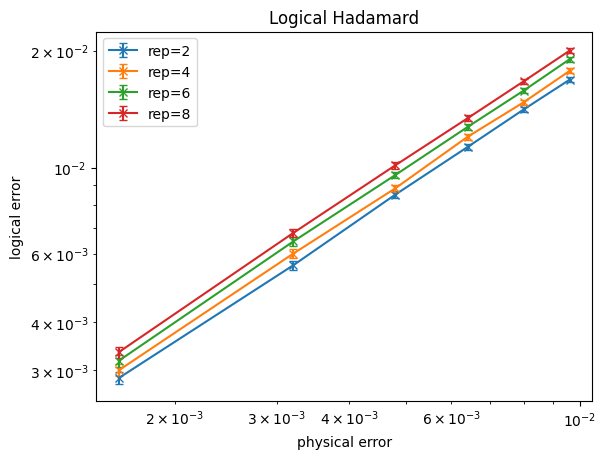

In [29]:
shots = int(1e6)
all_error = []
all_unc = []

for rep in range(2, 9, 2):
    logical_err = []
    unc = []
    for noise in range(len(one_qubit_noise)):
        qc = stim.Circuit()
        hadamard_circuit(qc, p1_err=one_qubit_noise[noise], p2_err=two_qubit_noise[noise], meas_err=0, rep=rep)

        dets, obs = qc.compile_detector_sampler().sample(shots=shots, separate_observables=True)
        err_rate, u = decoder(obs)
        logical_err.append(err_rate)
        unc.append(u)
    plt.errorbar(
        two_qubit_noise,
        logical_err,
        yerr=unc,
        fmt='-x',
        label=f'rep={rep}',
        capsize=3  # little horizontal caps on the error bars
    )
    all_error.append(logical_err)
    all_unc.append(unc)
    
plt.title('Logical Hadamard')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlabel('physical error')
plt.ylabel('logical error')

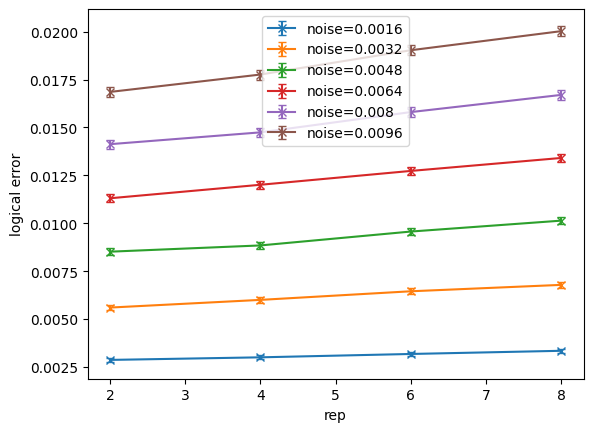

In [34]:
# all_error.shape == (num_reps, num_noises)
# uncertainties.shape == (num_reps, num_noises)
all_error = np.array(all_error)
all_unc = np.array(all_unc)
num_reps, num_noises = all_error.shape

x = range(2, 9, 2)

for k in range(num_noises):
    plt.errorbar(
        x,
        all_error[:, k],
        yerr=all_unc[:, k],
        fmt='-x',
        capsize=3,
        label=f'noise={two_qubit_noise[k]}'
    )

plt.legend()
plt.xlabel('rep')
plt.ylabel('logical error')
plt.show()

In [35]:
x = np.array(list(range(2, 9, 2)))
slopes = []

for k, noise in enumerate(two_qubit_noise):
    y = all_error[:, k]               # error vs rep for this noise
    m, b = np.polyfit(x, y, 1)
    slopes.append(m)
    print(f"noise={noise:0.5f} → slope = {m:.5f} per rep")

noise=0.00160 → slope = 0.00008 per rep
noise=0.00320 → slope = 0.00020 per rep
noise=0.00480 → slope = 0.00028 per rep
noise=0.00640 → slope = 0.00035 per rep
noise=0.00800 → slope = 0.00044 per rep
noise=0.00960 → slope = 0.00054 per rep
